<a href="https://colab.research.google.com/github/mAliAytekin/ai_notes/blob/main/image_processing_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNSIT VERİ SETİ İLE IMAGE PROCESSING


## MNSIT Veri seti hakkında Genel Bilgiler

El yazısı rakam tanıma için kullanılan veri setidir. Sınıflandırma algoritmalarını değerlendirmek için basit ve hızlı bir şekilde kullanılabilir. Aynı zamanda farklı algoritmaların performanslarını karşılaştırmada standart hale gelmiştir. Her ne kadar böyle olsa da genellikle oyuncak problemdir, çünkü gerçek dünya problemlerini tam yansıtmaz.

**Görüntü Özellikleri**
- 28x28 piksel gri tonlamalıdır.
- Her piksel 0-255 arası değerler almaktadır.
- 8-bit gri tonlamalıdır.
- 70000 adet görüntü içerir.
- Eğitim veri seti 60000 adet, test seti ise 10000 adettir.
- 10 farklı sınıftan oluşmaktadır.(0-9 arası rakamlar).
- Veriler genellikle 0-1 arasında normalize edilir.

**Tipik Başarı oranları**
- Basit MLP’lerle yapılan çalışmalarda %95 civarıdır.
- CNN ile bu başarı oranı %98-99 civarına çıkmaktadır.
- Daha ileri modeller ile %99.8 e kadar doğruluk elde edilebilmektedir.

# Veri Setinin Yüklenmesi & Data Augmentation





In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epoch_count=4

`torchvision`, PyTorch derin öğrenme çerçevesiyle birlikte kullanılan, özellikle bilgisayarla görme (computer vision) görevleri için tasarlanmış bir kütüphanedir.

**`torchvision` kütüphanesi ne içerir?**
*   **Veri Kümeleri (Datasets):** Popüler resim veri kümelerine (örneğin, MNIST, CIFAR-10, ImageNet) kolayca erişim ve bu veri kümelerini yükleme ve ön işleme (preprocessing) imkanı sunar.
*   **Model Mimarıları (Model Architectures):** Önceden eğitilmiş (pretrained) ve yaygın olarak kullanılan derin öğrenme modellerini (örneğin, ResNet, AlexNet, VGGNet) içerir. Bu modeller ile ince ayar (fine-tuning) yapabilir veya transfer öğrenimi (transfer learning) için temel olarak kullanılabilir.
*   **Görüntü Dönüşümleri (Image Transformations):** Resimleri yeniden boyutlandırma, kırpma, döndürme, normalleştirme (normalization) gibi çeşitli işlemlerden geçirmek için kullanılan fonksiyonlar ve sınıflar içerir. Bu dönüşümler, veri artırma (data augmentation) tekniklerini uygulamak için de kullanılır.
*   **Araçlar (Utilities):** Görüntüleri yükleme, kaydetme ve gösterme gibi işlemleri kolaylaştıran çeşitli araçlar ve fonksiyonlar sağlar.


In [ ]:
transform = transforms.Compose([
    transforms.Resize(32),  # ResNet 32x32 girdi ister
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

Derin öğrenme modelleri belirli özellikte veri formatı beklerler.
`transforms.Compose` ile bir araya getirilmiş birkaç temel dönüşüm adımını uygulanır.


1.  **`transforms.Resize(32)`:**
    *    Giriş resimlerinin boyutunu 32x32 piksele yeniden  Derin öğrenme modelleri genellikle belirli bir girdi boyutu bekler. ResNet gibi modellerin çoğu, bu kodda belirtildiği gibi 32x32 boyutunda girdilerle çalışmak üzere tasarlanmıştır. Bu dönüşüm, farklı boyutlardaki resimleri modele uygun hale getirir.

2.  **`transforms.ToTensor()`:**
    *   Resimleri NumPy dizilerinden veya PIL (Python Imaging Library) formatından PyTorch Tensörlerine dönüştürür.
    *    PyTorch, derin öğrenme modellerinde verileri işlemek için Tensörleri kullanır. Bu dönüşüm, resimleri modelin anlayabileceği bir formata sokar. Ayrıca, piksel değerlerini 0 ile 1 arasına normalleştirir (eğer orijinal değerler 0-255 aralığındaysa).

3.  **`transforms.Normalize((0.1307,), (0.3081,))`:**
    *  Resim verilerini belirtilen ortalama (`0.1307`) ve standart sapmaya (`0.3081`) göre normalleştirir.
    *   Normalleştirme, derin öğrenme modellerinin daha hızlı ve kararlı bir şekilde eğitilmesine yardımcı olur.  Girdi verilerinin dağılımını belirli bir aralığa (genellikle ortalaması 0 ve standart sapması 1 olacak şekilde) kaydırır ve ölçeklendirir.  Bu kodda kullanılan `0.1307` ve `0.3081` değerleri, genellikle MNIST veri kümesi gibi bir veri kümesinin (muhtemelen gri tonlamalı bir veri kümesi) ortalama ve standart sapmasıdır.  


In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

Yukarıdaki kodlarla veri seti indirilir ve eğitime hazır hale getirlir



1.  **`train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)`**:
    *   `transform=transform`: Veri setine uygulanacak dönüşümleri belirtir. `transform` değişkeni, verileri tensörlere dönüştürme ve normalleştirme gibi işlemleri içeren bir dönüşüm zincirini (sequence of transformations) tanımlar (bu kod parçasında tam olarak nasıl tanımlandığı gösterilmemiştir, ancak genelde `torchvision.transforms` modülü kullanılır).

2.  **`test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)`**:
    *   Bu satır, MNIST veri setinin **test** kısmını yükler.
    *   Parametreler önceki satırla aynıdır, ancak `train=False` olduğu için test kümesi yüklenecektir.

3.  **`train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)`**:
    *   Bu satır, eğitim veri seti için bir veri yükleyici (data loader) oluşturur.
    *   `DataLoader`: PyTorch'un `torch.utils.data` modülündeki veri yükleyici sınıfıdır.  Verileri mini-batch'lere ayırmak, karıştırmak (shuffle) ve paralel olarak yüklemek gibi işlemleri kolaylaştırır.
    *   `train_dataset`: Yükleyicinin kullanacağı veri setini belirtir (burada eğitim veri seti).
    *   `batch_size=64`: Her bir mini-batch'te kaç örnek (örneğin, kaç tane el yazısı rakamı) olacağını belirtir. Bu durumda, her mini-batch 64 örneğe sahip olacaktır.
    *   `shuffle=True`: Verilerin her epoch'ta karıştırılıp karıştırılmayacağını belirtir. `True` olduğunda, her epoch'ta veri sırası rastgele karıştırılır, bu da modelin genelleme yeteneğini artırır.

4.  **`test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)`**:
    *   Bu satır, test veri seti için bir veri yükleyici oluşturur.
    *   `test_dataset`: Yükleyicinin kullanacağı veri setini belirtir (burada test veri seti).
    *   `batch_size=1000`: Her bir mini-batch'te kaç örnek olacağını belirtir.  Test aşamasında genellikle daha büyük batch boyutları kullanılır.
    *   `shuffle=False`: Test verilerinin karıştırılmayacağını belirtir. Test verilerinin sırası genellikle önemlidir (örneğin, sonuçları karşılaştırmak için).


# **Çözüm Teknikleri**








## RESNet

RESNet, kaybolan/patlayan gradyan sorununu çözmek için geliştirilmiş bir sinir ağır mimarisidir. Bu ağda, atlama bağlantıları (skip connections) adı verilen bir teknikle bir katmanın aktivasyonlarını, aradaki bazı katmanları atlayarak daha ileriki katmanlara bağlar. Bu da, bir artık bloğu (residual blocks) oluşturur. Resnet'ler, bu artık bloklarının üst üste yığılmasıyla oluşturulur.

`resnet18`, RESNet ailesinin en küçük modelidir. mimari özellikleri şunlardır:
- 18 katmanlı derin sinir ağı
- her grubu farklı boyutlarda feature map'ler üreten 4 ana residual block grubu
- ilk katmanda => 7x7 convolution + batch normalization + ReLU
- son katmanda => global average pooling + fully connected


**Residual block** mimarisi de şöyledir:

Giriş → Conv3x3 → BatchNorm → ReLU → Conv3x3 → BatchNorm → (+) → ReLU    
 ↓ →→→→→→→→→→→ Skip Connection →→→→→→→→→→→→ ↑


In [ ]:
transform = transforms.Compose([
    transforms.Resize(32),  # ResNet 32x32 girdi ister
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [ ]:
from torchvision.models import resnet18
class MNISTResNet(nn.Module):
    def __init__(self):
        super(MNISTResNet, self).__init__()
        self.model = resnet18(num_classes=10)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    def forward(self, x):
        return self.model(x)

In [ ]:
resnet_model = MNISTResNet().to(device)
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
resnet_train_losses = []
for epoch in range(epoch_count):
    running_loss = 0.0
    resnet_model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = resnet_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    resnet_train_losses.append(avg_loss)
    print(f"Epoch {epoch}, Loss: {avg_loss}")

Epoch 0, Loss: 0.12624822848085274
Epoch 1, Loss: 0.05883330605434639
Epoch 2, Loss: 0.0431892377498653
Epoch 3, Loss: 0.03915018342820846


In [ ]:
resnet_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = resnet_model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
resnet_accracy = 100 * correct / total
print('Test accuracy:', correct / total)

Test accuracy: 0.9907


## MLP

Aşağıda, 3 katmanlı bir MLP tanımlanmıştır.
Aktivasyon fonksiyonu olarak ReLU kullanılmıştır.


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
simple_mlp = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_mlp.parameters(), lr=0.001)

In [ ]:
epochs = 3
simple_mlp_train_losses = []
simple_mlp.train()
for epoch in range(epoch_count):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        images = images.to(device)
        labels = labels.to(device)
        outputs = simple_mlp(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    simple_mlp_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss}")

Epoch 1, Loss: 0.3493419737854937
Epoch 2, Loss: 0.1392149532765849
Epoch 3, Loss: 0.09563315830636285
Epoch 4, Loss: 0.07160274264092908


In [ ]:
simple_mlp.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = simple_mlp(data)
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == targets).sum().item()
        total += targets.size(0)
simple_mlp_accracy = 100 * correct / total
print(f'Test Accuracy: {correct/total:.4f}')

Test Accuracy: 0.9691


## CNN

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))])

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 14 * 14)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simple_cnn = SimpleCNN().to(device)
optimizer = optim.Adam(simple_cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
simple_cnn_train_losses = []
for epoch in range(epoch_count):
    simple_cnn.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = simple_cnn(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    simple_cnn_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss}")


Epoch 1, Loss: 0.1399961308417802
Epoch 2, Loss: 0.048743398858111166
Epoch 3, Loss: 0.03374405502437749
Epoch 4, Loss: 0.025393988506709993


In [ ]:
simple_cnn.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = simple_cnn(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

simple_cnn_accracy = 100 * correct / total
print(f'Test Accuracy: {correct/total:.4f}')

Test Accuracy: 0.9898


# Sonuçlar



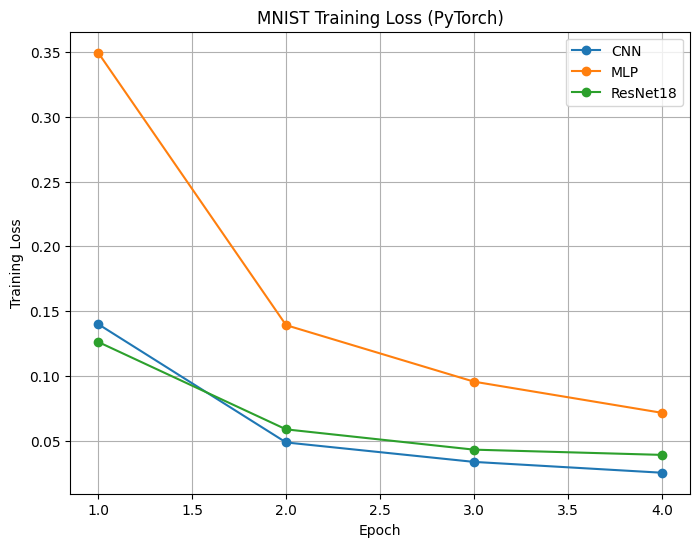

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(range(1, epoch_count+1), simple_cnn_train_losses, marker='o',label='CNN')
plt.plot(range(1, epoch_count+1), simple_mlp_train_losses, marker='o',label='MLP')
plt.plot(range(1, epoch_count+1), resnet_train_losses, marker='o',label='ResNet18')
plt.xlabel("Epoch" )
plt.ylabel("Training Loss" )
plt.title("MNIST Training Loss (PyTorch)" )
plt.legend()
plt.grid(True)
plt.show()

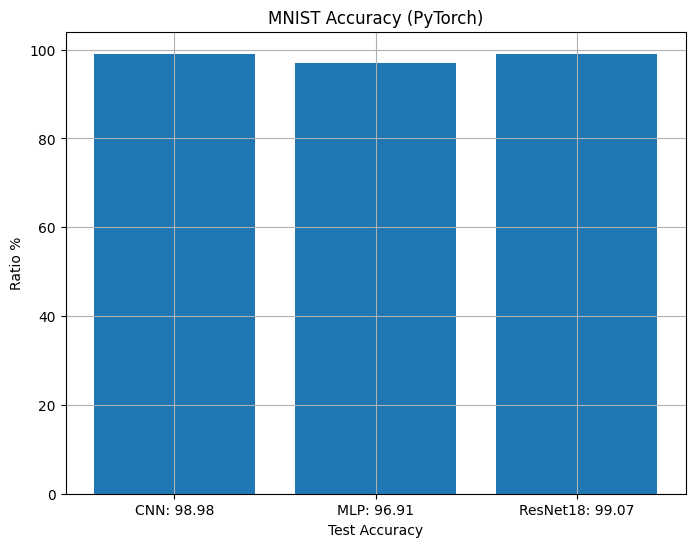

In [ ]:
plt.figure(figsize=(8,6))
plt.ylabel("Ratio %" )
plt.xlabel("Test Accuracy" )
plt.title("MNIST Accuracy (PyTorch)" )
plt.bar(['CNN: '+str(simple_cnn_accracy), 'MLP: '+str(simple_mlp_accracy), 'ResNet18: '+str(resnet_accracy)],
 [simple_cnn_accracy, simple_mlp_accracy, resnet_accracy])
plt.grid(True)
plt.show()

## Kaynaklar

- Gemini
- Claude Sonnet 4
- https://tr.d2l.ai/index.html
- https://www.geeksforgeeks.org/residual-networks-resnet-deep-learning/
- https://www.geeksforgeeks.org/resnet18-from-scratch-using-pytorch/
- https://kindxiaoming.github.io/pykan/intro.html
- https://www.geeksforgeeks.org/introduction-convolution-neural-network/